In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
file_path = "/content/Pocra_district All Final Data_FINAL3MAY.xlsx"

In [ ]:
sheets = pd.read_excel(file_path, sheet_name=None)

dfs = []
for sheet_name, df in sheets.items():
    if isinstance(df, pd.DataFrame) and not df.empty:
        df.columns = [col.strip().lower() for col in df.columns]
        if sheet_name.lower() == 'hingoli':
            cols = df.columns.tolist()
            if 'ud ld' in cols:
                idx = cols.index('ud ld')
                if idx + 1 < len(cols):
                    next_col = cols[idx + 1]
                    if next_col.strip() == '' or df[next_col].isna().all() or (df[next_col] == '').all():
                        df = df.rename(columns={'ud ld': 'ud', next_col: 'ld'})
        if 'lat' in df.columns:
            df['district'] = sheet_name
            dfs.append(df)


if dfs:
    df_merged = pd.concat(dfs, ignore_index=True)
    cols = df_merged.columns.tolist()
    lat_index = cols.index('lat')
    cols.insert(lat_index, cols.pop(cols.index('district')))
    df_merged = df_merged[cols]
    df_merged['lat'] = df_merged['lat'].ffill()
    df_merged['long'] = df_merged['long'].ffill()
    # print(df_merged)
else:
    print("No sheets with data and a 'lat' column were found.")

# df_merged.columns

In [ ]:
def combine_columns(df, col_list, new_col):
    for col in col_list:
        if col in df.columns:
            if new_col in df.columns:
                df[new_col] = df[new_col].combine_first(df[col])
            else:
                df[new_col] = df[col]
    return df

col_variants = {
    'ud': ['ud', 'ud ld'],
    'ld': ['ld', 'unnamed: 4'],
    'site_id': ['site_id', 'unnamed: 3'],
    'bulk density': ['bulk density', 'bd'],
    'sand%': ['sand%', 'sand %'],
    'lab no.': ['lab no.', 'lab no', 'lab  no.'],
}

for main_col, variants in col_variants.items():
    df_merged = combine_columns(df_merged, variants, main_col)

to_drop = []
for main_col, variants in col_variants.items():
    for v in variants:
        if v != main_col and v in df_merged.columns:
            to_drop.append(v)
if to_drop:
    df_merged.drop(columns=to_drop, inplace=True)

cols = df_merged.columns.tolist()
main_cols = ['ud', 'ld', 'lab no.']
long_idx = cols.index('long') + 1
for c in reversed(main_cols):
    if c in cols:
        cols.insert(long_idx, cols.pop(cols.index(c)))
df_merged = df_merged[cols]
df_merged.drop(columns=['pwp.1', 'fc.1', 'awc.1'], inplace=True)
print(df_merged.columns)


Index(['profile no.', 'district', 'lat', 'long', 'ud', 'ld', 'lab no.', 'ph',
       'ec mscm-1', 'organic carbon %', 'caco3 %', 'ex. ca+mg meq/100g soil',
       'ex.ca meq/100g soil', 'ex.mg meq/100g soil', 'ex.na meq/100g soil',
       'ex.k meq/100g soil', 'sum', 'cec cmol(p+)kg-1', 'base saturation %',
       'av.n kg/ha', 'av.p kg/ha', 'av. k kg/ha', 'fe mg/kg', 'mn mg/kg',
       'cu mg/kg', 'zn mg/kg', 'sand%', '% clay', 'silt%', 'texture',
       'bulk density', '1/3 bar %', '15 bar%', 'awc', 'wilting point',
       'field capacity', 'pwp', 'fc', 'site_id'],
      dtype='object')


/tmp/ipython-input-4-1976313486.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_merged.drop(columns=['pwp.1', 'fc.1', 'awc.1'], inplace=True)


In [ ]:
df_merged.to_csv('nbss_all_villages_new.csv', index=False)
from google.colab import files
files.download('nbss_all_villages_new.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
latur = df_merged[:]
latur

,profile no.,district,lat,long,ud,ld,lab no.,ph,ec mscm-1,organic carbon %,...,texture,bulk density,1/3 bar %,15 bar%,awc,wilting point,field capacity,pwp,fc,site_id
0,P1/1,Latur,18.380304,76.517363,0.0,18.0,1.0,8.38,0.178,0.636364,...,Silty Clay,1.700000,37.704918,24.229075,13.475843,0.328,0.481,NaN,NaN,NaN
1,P1/2,Latur,18.380304,76.517363,18.0,52.0,2.0,8.50,0.192,0.454545,...,Clay,1.300000,38.235294,22.767857,15.467437,0.403,0.539,NaN,NaN,NaN
2,P1/3,Latur,18.380304,76.517363,52.0,68.0,3.0,8.66,0.192,0.363636,...,Clay,1.686532,41.409692,27.615063,13.794629,0.383,0.524,NaN,NaN,NaN
3,P1/4,Latur,18.380304,76.517363,68.0,90.0,4.0,8.60,0.208,0.333333,...,Clay,1.747535,32.706767,20.425532,12.281235,0.357,0.502,NaN,NaN,NaN
4,P1/5,Latur,18.380304,76.517363,90.0,150.0,5.0,8.62,0.238,0.272727,...,Clay,1.484536,37.759336,24.390244,13.369092,0.357,0.504,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1996,Poc/Osm/P42,Osmanabad,18.230149,76.220952,0.0,10.0,2128,NaN,0.240,0.844221,...,Clay,1.244355,NaN,NaN,14.800000,0.348,0.496,24.8,39.6,NaN
1997,NaN,Osmanabad,18.230149,76.220952,10.0,30.0,2129,NaN,0.334,0.331658,...,Clay,1.247951,NaN,NaN,15.100000,0.335,0.486,23.5,38.6,NaN
1998,NaN,Osmanabad,18.230149,76.220952,30.0,50.0,2130,NaN,0.259,0.512563,...,Clay,1.258300,NaN,NaN,15.000000,0.385,0.525,28.5,43.5,NaN
1999,NaN,Osmanabad,18.230149,76.220952,50.0,80.0,2131,NaN,0.288,0.361809,...,Clay,1.254000,NaN,NaN,14.100000,0.382,0.523,28.2,42.3,NaN


In [ ]:
latur.columns

Index(['profile no.', 'district', 'lat', 'long', 'ud', 'ld', 'lab no.', 'ph',
       'ec mscm-1', 'organic carbon %', 'caco3 %', 'ex. ca+mg meq/100g soil',
       'ex.ca meq/100g soil', 'ex.mg meq/100g soil', 'ex.na meq/100g soil',
       'ex.k meq/100g soil', 'sum', 'cec cmol(p+)kg-1', 'base saturation %',
       'av.n kg/ha', 'av.p kg/ha', 'av. k kg/ha', 'fe mg/kg', 'mn mg/kg',
       'cu mg/kg', 'zn mg/kg', 'sand%', '% clay', 'silt%', 'texture',
       'bulk density', '1/3 bar %', '15 bar%', 'awc', 'wilting point',
       'field capacity', 'pwp', 'fc', 'site_id'],
      dtype='object')

In [ ]:
latur['base saturation %'] = latur['base saturation %'].replace(r'^\s*$', np.nan, regex=True)

# latur['Base Saturation %'] = pd.to_numeric(latur['Base Saturation %'], errors='coerce')


<ipython-input-8-1879010153>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  latur['base saturation %'] = latur['base saturation %'].replace(r'^\s*$', np.nan, regex=True)


In [ ]:
latur.shape
latur["base saturation %"].mean()

np.float64(100.3610879879247)

In [ ]:
mean_df = latur[['ph', 'ec mscm-1', 'organic carbon %', 'caco3 %', 'ex. ca+mg meq/100g soil',
       'ex.ca meq/100g soil', 'ex.mg meq/100g soil', 'ex.na meq/100g soil',
       'ex.k meq/100g soil', 'cec cmol(p+)kg-1', 'base saturation %',
       'av.n kg/ha', 'av.p kg/ha', 'av. k kg/ha', 'fe mg/kg', 'mn mg/kg',
       'cu mg/kg', 'zn mg/kg', 'sand%', '% clay', 'silt%',
       'bulk density', '1/3 bar %', '15 bar%', 'awc', 'wilting point',
       'field capacity', 'pwp', 'fc']].mean().to_frame().T
mean_df

,ph,ec mscm-1,organic carbon %,caco3 %,ex. ca+mg meq/100g soil,ex.ca meq/100g soil,ex.mg meq/100g soil,ex.na meq/100g soil,ex.k meq/100g soil,cec cmol(p+)kg-1,...,% clay,silt%,bulk density,1/3 bar %,15 bar%,awc,wilting point,field capacity,pwp,fc
0,8.250635,0.221514,0.467076,8.670341,48.782807,35.740302,13.041705,1.633625,0.512537,51.864706,...,51.814052,34.516474,1.311028,35.88644,22.762122,13.707809,0.285127,0.427106,19.640474,33.860513


# Correlation Analysis

In [ ]:
df = pd.DataFrame(latur)
for_num_data = df[['ph', 'ec mscm-1', 'organic carbon %', 'caco3 %', 'ex. ca+mg meq/100g soil',
       'ex.ca meq/100g soil', 'ex.mg meq/100g soil', 'ex.na meq/100g soil',
       'ex.k meq/100g soil', 'cec cmol(p+)kg-1', 'base saturation %',
       'av.n kg/ha', 'av.p kg/ha', 'av. k kg/ha', 'fe mg/kg', 'mn mg/kg',
       'cu mg/kg', 'zn mg/kg', 'sand%', '% clay', 'silt%',
       'bulk density', '1/3 bar %', '15 bar%', 'awc', 'wilting point',
       'field capacity', 'pwp', 'fc']]
matrix = for_num_data.corr()

In [ ]:
matrix

,ph,ec mscm-1,organic carbon %,caco3 %,ex. ca+mg meq/100g soil,ex.ca meq/100g soil,ex.mg meq/100g soil,ex.na meq/100g soil,ex.k meq/100g soil,cec cmol(p+)kg-1,...,% clay,silt%,bulk density,1/3 bar %,15 bar%,awc,wilting point,field capacity,pwp,fc
ph,1.000000,0.319185,-0.387821,0.434012,0.108903,0.041183,0.159669,0.385311,-0.007019,0.079760,...,0.190917,-0.084582,-0.046819,0.174050,0.020344,0.175884,-0.105697,-0.126756,-0.103122,-0.074367
ec mscm-1,0.319185,1.000000,-0.064530,0.190391,-0.079178,-0.192454,0.212460,0.447406,0.091242,0.001129,...,0.102464,0.002776,-0.028123,0.307021,0.124825,0.166991,-0.045344,-0.048515,-0.043800,-0.015620
organic carbon %,-0.387821,-0.064530,1.000000,-0.224130,0.133080,0.191014,-0.090630,-0.217778,0.297036,0.163977,...,0.086716,0.011905,-0.051114,0.082237,0.114546,-0.038587,0.011240,0.008169,-0.104086,-0.084091
caco3 %,0.434012,0.190391,-0.224130,1.000000,-0.149153,-0.141112,-0.045347,0.170266,-0.035568,-0.161119,...,-0.017214,-0.050188,-0.135260,-0.078582,-0.129051,0.066094,0.062091,0.065705,0.188776,0.178346
ex. ca+mg meq/100g soil,0.108903,-0.079178,0.133080,-0.149153,1.000000,0.891503,0.412199,-0.080564,0.198356,0.684962,...,0.393437,0.033564,-0.142373,0.498571,0.411609,0.100440,0.155275,0.141217,0.077868,0.106414
ex.ca meq/100g soil,0.041183,-0.192454,0.191014,-0.141112,0.891503,1.000000,-0.045261,-0.169637,0.206797,0.656997,...,0.294636,0.018361,-0.144348,0.322821,0.294203,0.041283,0.107949,0.095357,0.047257,0.069388
ex.mg meq/100g soil,0.159669,0.212460,-0.090630,-0.045347,0.412199,-0.045261,1.000000,0.163550,0.021614,0.263357,...,0.273705,0.036605,-0.015100,0.447234,0.313697,0.138362,0.127473,0.121578,0.078062,0.096867
ex.na meq/100g soil,0.385311,0.447406,-0.217778,0.170266,-0.080564,-0.169637,0.163550,1.000000,0.000621,-0.027846,...,0.205081,-0.028067,-0.028740,0.339406,0.142105,0.118045,0.023356,0.009092,0.071973,0.086140
ex.k meq/100g soil,-0.007019,0.091242,0.297036,-0.035568,0.198356,0.206797,0.021614,0.000621,1.000000,0.204765,...,0.148718,0.068239,-0.053824,0.271905,0.206617,0.069833,0.042951,0.046654,0.023432,0.040629
cec cmol(p+)kg-1,0.079760,0.001129,0.163977,-0.161119,0.684962,0.656997,0.263357,-0.027846,0.204765,1.000000,...,0.359847,0.056057,-0.083550,0.674552,0.324418,0.107005,0.089505,0.081598,-0.008163,0.023817


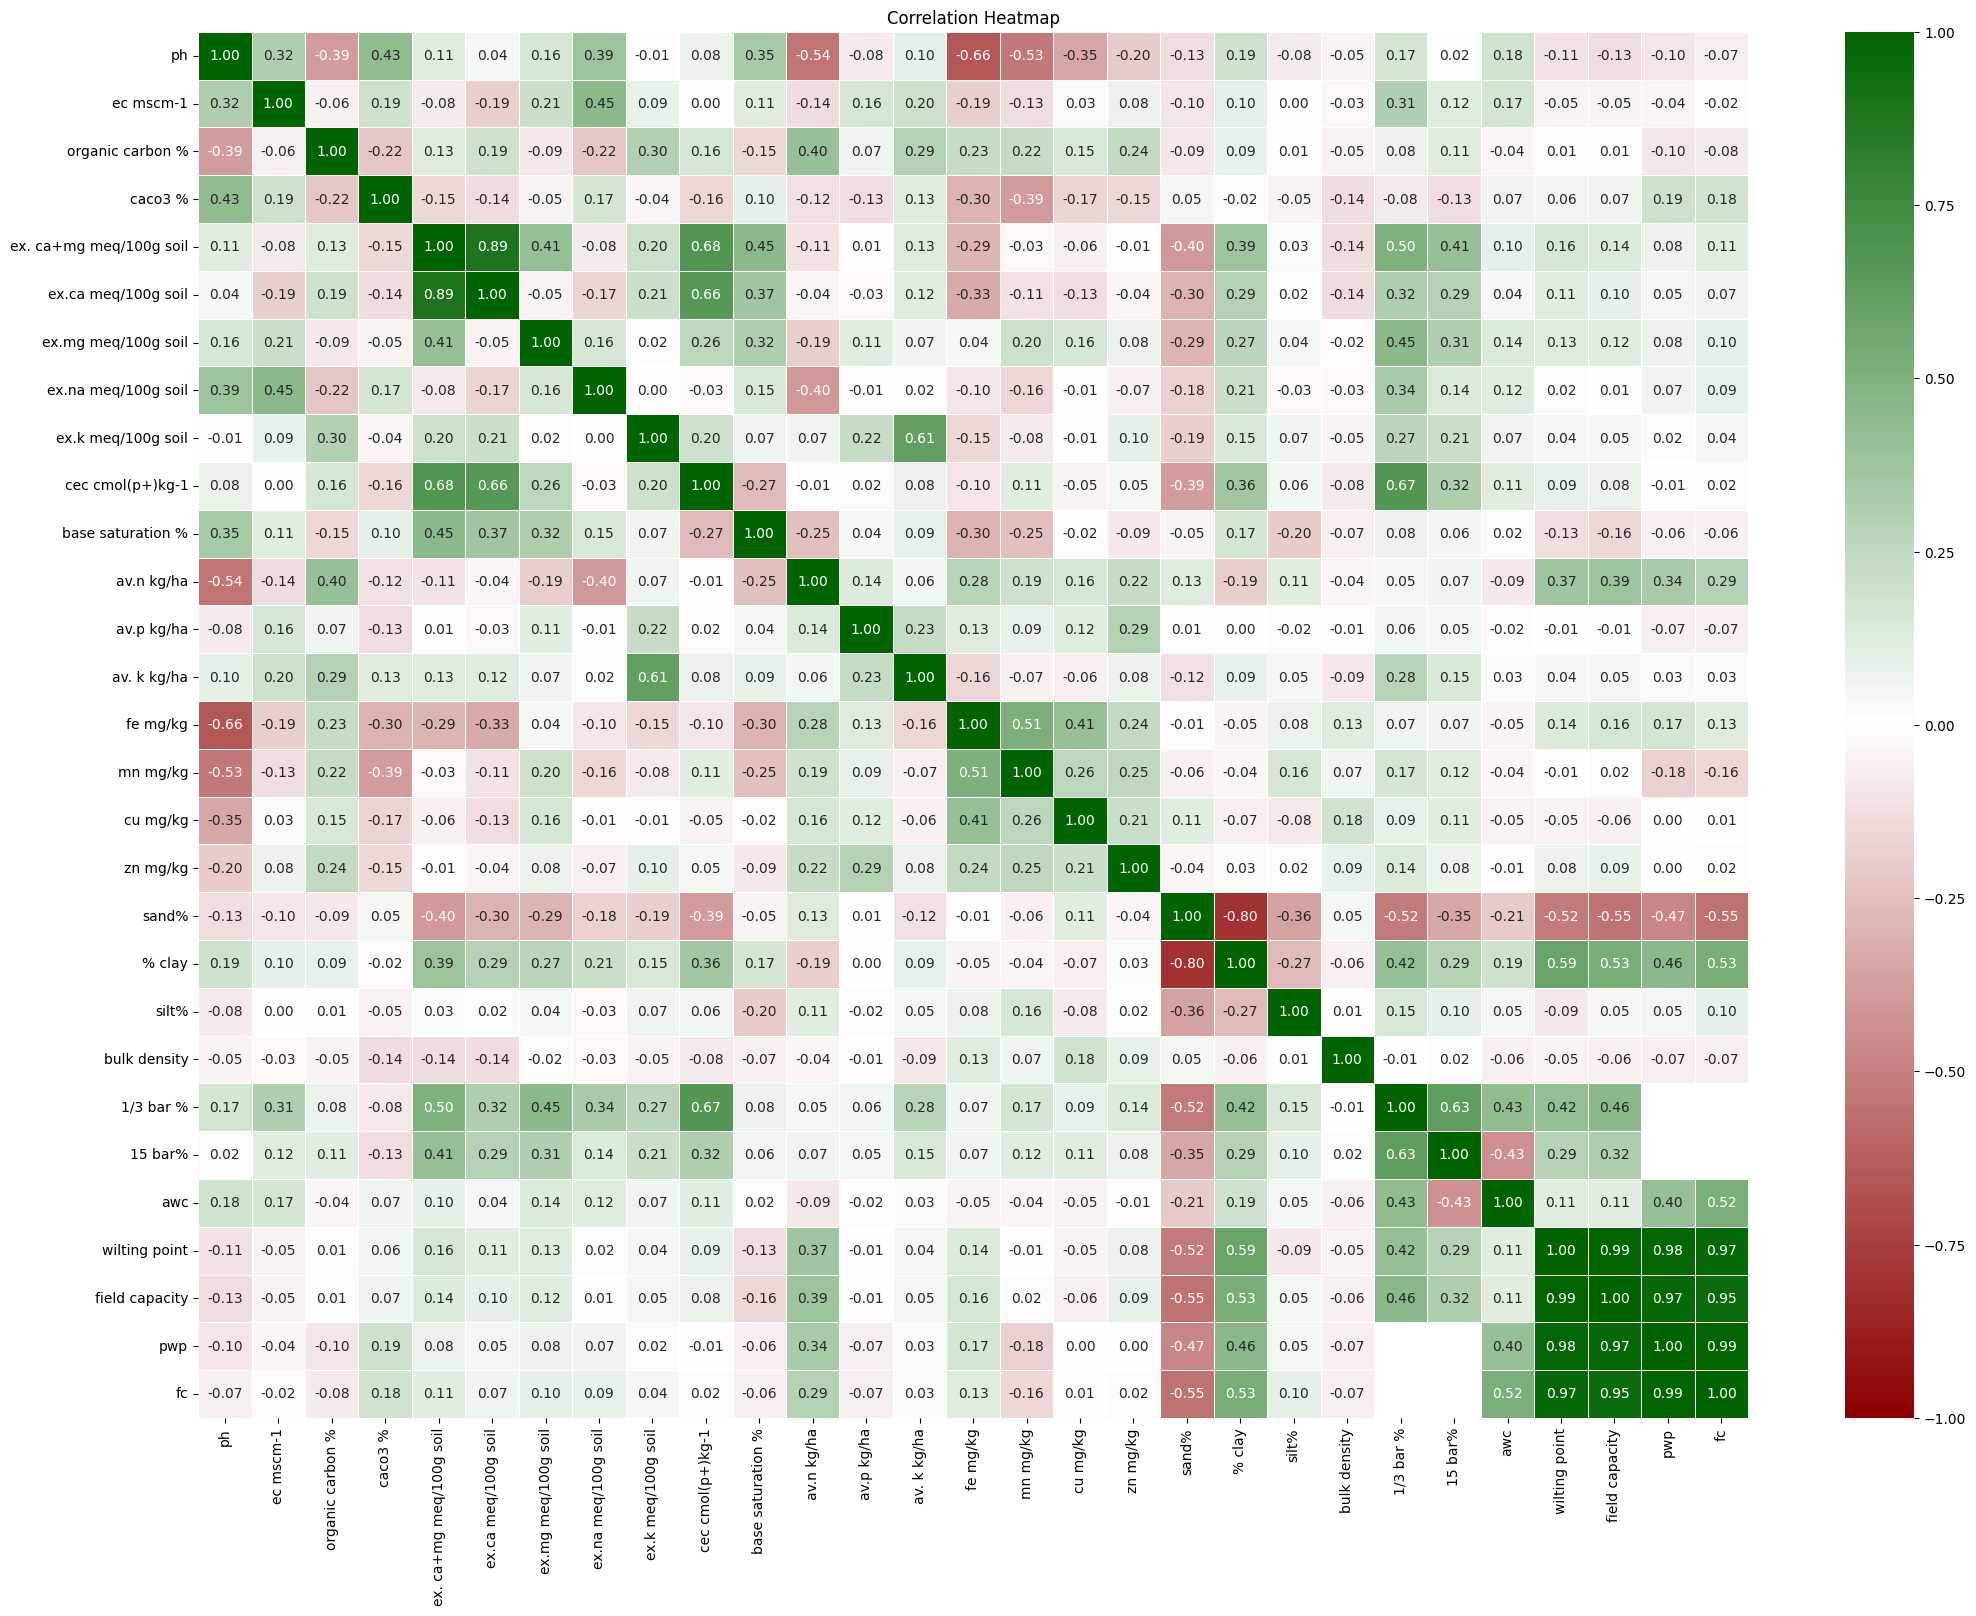

In [ ]:
from matplotlib.colors import LinearSegmentedColormap
cmap = LinearSegmentedColormap.from_list(
    "red_white_green", ["darkred", "white", "darkgreen"]
)

plt.figure(figsize=(25, 18))
sns.heatmap(
    matrix.round(2),
    annot=True,
    fmt=".2f",
    cmap=cmap,
    vmin=-1, vmax=1,
    linewidths=0.5,
    cbar=True
)
plt.title("Correlation Heatmap")
plt.show()

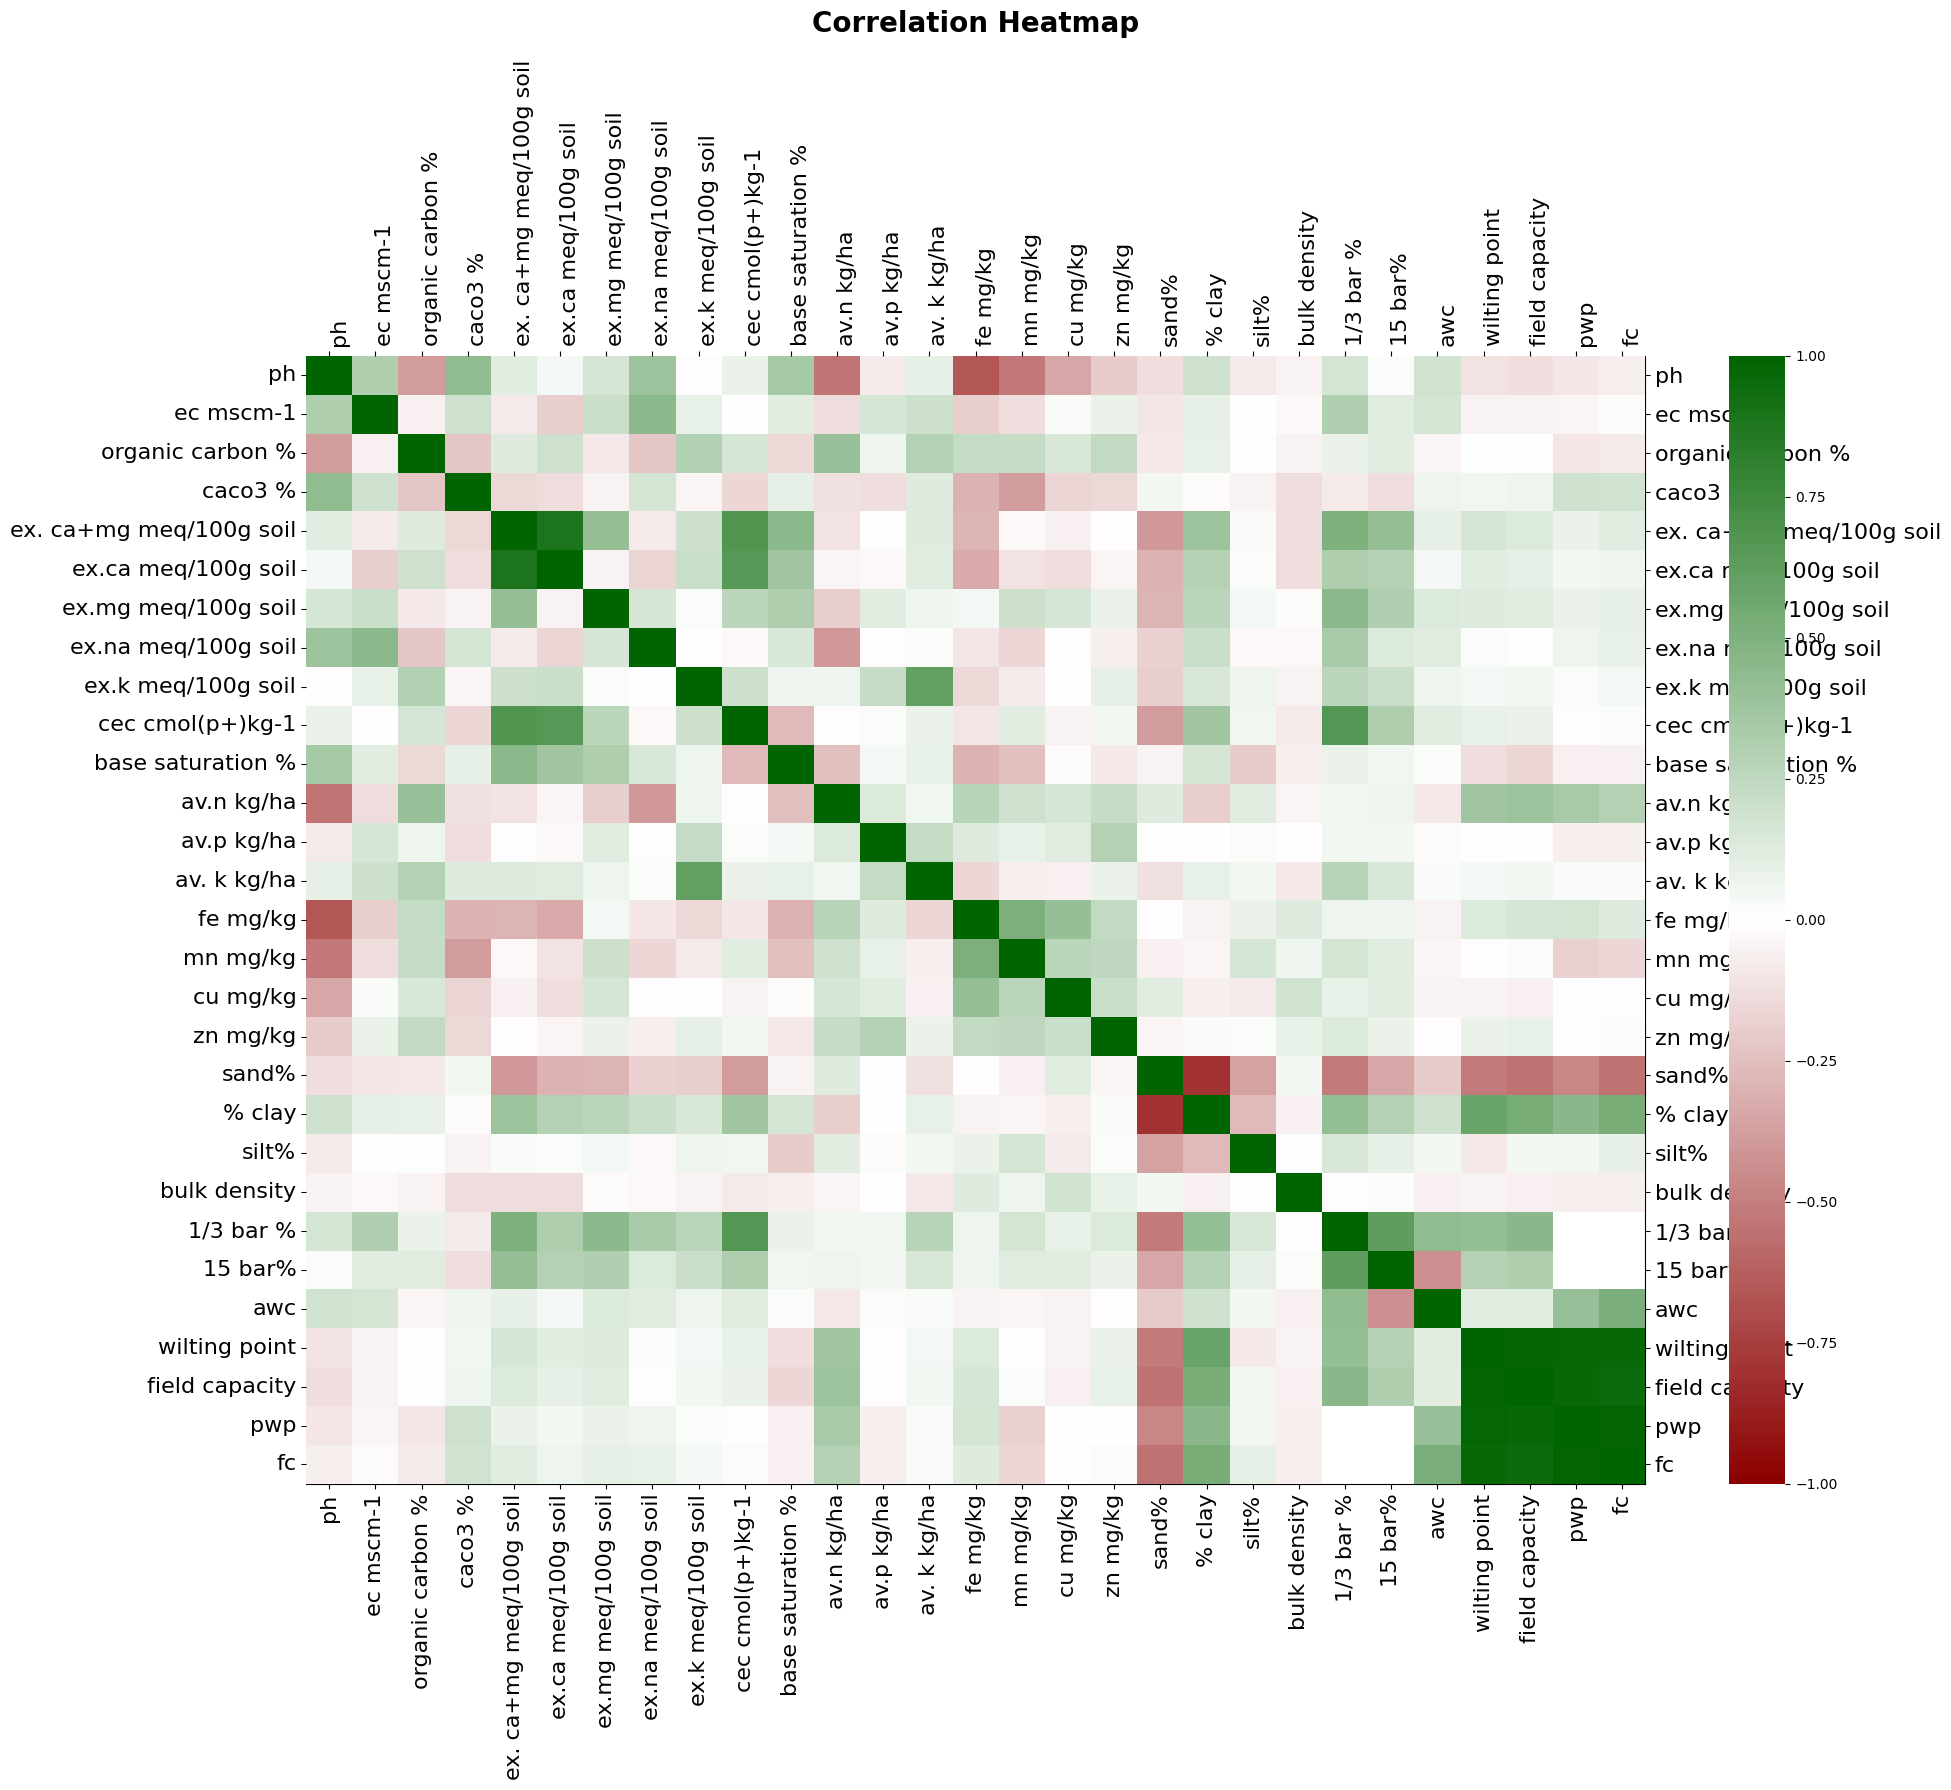

In [ ]:
cmap = LinearSegmentedColormap.from_list("red_white_green", ["darkred", "white", "darkgreen"])

plt.figure(figsize=(20, 18))

ax = sns.heatmap(
    matrix.round(2),
    # annot=True,
    fmt=".2f",
    cmap=cmap,
    vmin=-1, vmax=1,
    linewidths=0,
    cbar=True,
    xticklabels=True,   # Show x-axis (column) labels
    yticklabels=True    # Show y-axis (row) labels
)

ax.set_xticklabels(ax.get_xticklabels(), fontsize=16)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=16)

plt.title("Correlation Heatmap", fontsize=20, fontweight='bold', pad=20)

# Put column labels at the top as well as bottom
ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')
plt.xticks(rotation=90, ha='left')

# Duplicate the x-axis tick labels at the bottom
ax_secondary = ax.secondary_xaxis('bottom')
ax_secondary.set_xticks(ax.get_xticks())
ax_secondary.set_xticklabels(ax.get_xticklabels(), fontsize=16)
ax_secondary.tick_params(axis='x', rotation=90)

# Duplicate the y-axis tick labels at the right
ax_secondary_y = ax.secondary_yaxis('right')
ax_secondary_y.set_yticks(ax.get_yticks())
ax_secondary_y.set_yticklabels(ax.get_yticklabels(), fontsize=16)
ax_secondary_y.tick_params(axis='y')

plt.tight_layout()
plt.show()

In [ ]:
corr_pairs = (
    matrix.stack()
    .reset_index()
    .rename(columns={'level_0': 'Parameter 1', 'level_1': 'Parameter 2', 0: 'Correlation Value'})
)

corr_pairs = corr_pairs[corr_pairs['Parameter 1'] != corr_pairs['Parameter 2']]


corr_pairs['set'] = corr_pairs.apply(lambda x: frozenset([x['Parameter 1'], x['Parameter 2']]), axis=1)
corr_pairs = corr_pairs.drop_duplicates('set').drop(columns='set').reset_index(drop=True)

corr_pairs['Direction'] = np.where(corr_pairs['Correlation Value'] > 0, 'Positive', 'Negative')

def get_inference(x):
    abs_x = abs(x)
    if abs_x >= 0.7:
        return 'Very Strong'
    elif abs_x >= 0.5:
        return 'Strong'
    elif abs_x >= 0.25:
        return 'Good'
    elif abs_x >= 0.1:
        return 'Weak'
    else:
        return 'Very Weak'

corr_pairs['Inferance'] = corr_pairs['Correlation Value'].apply(get_inference)
corr_pairs['Correlation Value'] = corr_pairs['Correlation Value'].round(2)

final_corr_df = corr_pairs[['Parameter 1', 'Parameter 2', 'Correlation Value', 'Direction', 'Inferance']]

final_corr_df


,Parameter 1,Parameter 2,Correlation Value,Direction,Inferance
0,ph,ec mscm-1,0.32,Positive,Good
1,ph,organic carbon %,-0.39,Negative,Good
2,ph,caco3 %,0.43,Positive,Good
3,ph,ex. ca+mg meq/100g soil,0.11,Positive,Weak
4,ph,ex.ca meq/100g soil,0.04,Positive,Very Weak
...,...,...,...,...,...
397,wilting point,pwp,0.98,Positive,Very Strong
398,wilting point,fc,0.97,Positive,Very Strong
399,field capacity,pwp,0.97,Positive,Very Strong
400,field capacity,fc,0.95,Positive,Very Strong


In [ ]:
def highlight_row(row):
    corr = row['Correlation Value']
    if corr >= 0.25:
        return ['background-color: #b6ffb6'] * len(row)  # light green
    elif corr <= -0.25:
        return ['background-color: #ffcccc'] * len(row)  # light red
    else:
        return [''] * len(row)

styled_df = final_corr_df.style.apply(highlight_row, axis=1)

styled_df


,Parameter 1,Parameter 2,Correlation Value,Direction,Inferance
0,ph,ec mscm-1,0.320000,Positive,Good
1,ph,organic carbon %,-0.390000,Negative,Good
2,ph,caco3 %,0.430000,Positive,Good
3,ph,ex. ca+mg meq/100g soil,0.110000,Positive,Weak
4,ph,ex.ca meq/100g soil,0.040000,Positive,Very Weak
5,ph,ex.mg meq/100g soil,0.160000,Positive,Weak
6,ph,ex.na meq/100g soil,0.390000,Positive,Good
7,ph,ex.k meq/100g soil,-0.010000,Negative,Very Weak
8,ph,cec cmol(p+)kg-1,0.080000,Positive,Very Weak
9,ph,base saturation %,0.350000,Positive,Good


In [ ]:
filtered_df = final_corr_df[
    (final_corr_df['Correlation Value'] >= 0.25) | (final_corr_df['Correlation Value'] <= -0.25)
].reset_index(drop=True)

filtered_df.style.apply(highlight_row, axis=1)

,Parameter 1,Parameter 2,Correlation Value,Direction,Inferance
0,ph,ec mscm-1,0.320000,Positive,Good
1,ph,organic carbon %,-0.390000,Negative,Good
2,ph,caco3 %,0.430000,Positive,Good
3,ph,ex.na meq/100g soil,0.390000,Positive,Good
4,ph,base saturation %,0.350000,Positive,Good
5,ph,av.n kg/ha,-0.540000,Negative,Strong
6,ph,fe mg/kg,-0.660000,Negative,Strong
7,ph,mn mg/kg,-0.530000,Negative,Strong
8,ph,cu mg/kg,-0.350000,Negative,Good
9,ec mscm-1,ex.na meq/100g soil,0.450000,Positive,Good


In [ ]:
def get_corr_dict(df, direction):
    corr_dict = {}
    for _, row in df[df['Direction'] == direction].iterrows():
        corr_dict.setdefault(row['Parameter 1'], []).append(row['Parameter 2'])
        corr_dict.setdefault(row['Parameter 2'], []).append(row['Parameter 1'])

    for k in corr_dict:
        corr_dict[k] = list(sorted(set(corr_dict[k])))
    return corr_dict

pos_corr = get_corr_dict(filtered_df, 'Positive')
neg_corr = get_corr_dict(filtered_df, 'Negative')

all_params = sorted(set(list(pos_corr.keys()) + list(neg_corr.keys())))

summary_rows = []
for param in all_params:
    pos_with = ", ".join(pos_corr.get(param, []))
    neg_with = ", ".join(neg_corr.get(param, []))
    summary_rows.append({
        'Parameter': param,
        'Positive correlation with': pos_with,
        'Negative correlation with': neg_with
    })

summary_df = pd.DataFrame(summary_rows)
summary_df

,Parameter,Positive correlation with,Negative correlation with
0,% clay,"1/3 bar %, 15 bar%, cec cmol(p+)kg-1, ex. ca+m...","sand%, silt%"
1,1/3 bar %,"% clay, 15 bar%, av. k kg/ha, awc, cec cmol(p+...",sand%
2,15 bar%,"% clay, 1/3 bar %, cec cmol(p+)kg-1, ex. ca+mg...","awc, sand%"
3,av. k kg/ha,"1/3 bar %, ex.k meq/100g soil, organic carbon %",
4,av.n kg/ha,"fc, fe mg/kg, field capacity, organic carbon %...","base saturation %, ex.na meq/100g soil, ph"
5,av.p kg/ha,zn mg/kg,
6,awc,"1/3 bar %, fc, pwp",15 bar%
7,base saturation %,"ex. ca+mg meq/100g soil, ex.ca meq/100g soil, ...","av.n kg/ha, cec cmol(p+)kg-1, fe mg/kg, mn mg/kg"
8,caco3 %,ph,"fe mg/kg, mn mg/kg"
9,cec cmol(p+)kg-1,"% clay, 1/3 bar %, 15 bar%, ex. ca+mg meq/100g...","base saturation %, sand%"


In [ ]:
summary_df.to_csv('overall_correlation.csv', index=False)
from google.colab import files
files.download('overall_correlation.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

marathawada, vidarbha
layer-wise
ydata profiling

# EDA Analysis

In [ ]:
print("Basic Overview:")
print("Shape:", latur.shape)
print("\nColumn Types:\n", latur.dtypes)
print("\nFirst 5 rows:\n", latur.head())
print("\nSummary (numerical):\n", latur.describe())
print("\nSummary (categorical):\n", latur.describe(include='object'))
print("\nMissing values:\n", latur.isnull().sum())

Basic Overview:
Shape: (2001, 39)

Column Types:
 profile no.                 object
district                    object
lat                        float64
long                       float64
ud                         float64
ld                         float64
lab no.                     object
ph                         float64
ec mscm-1                  float64
organic carbon %           float64
caco3 %                    float64
ex. ca+mg meq/100g soil    float64
ex.ca meq/100g soil        float64
ex.mg meq/100g soil        float64
ex.na meq/100g soil        float64
ex.k meq/100g soil         float64
sum                        float64
cec cmol(p+)kg-1           float64
base saturation %          float64
av.n kg/ha                 float64
av.p kg/ha                 float64
av. k kg/ha                float64
fe mg/kg                   float64
mn mg/kg                   float64
cu mg/kg                   float64
zn mg/kg                   float64
sand%                      float64
% cla

In [ ]:
for col in latur.columns:
    print(f"\n--- {col} ---")
    print("Unique values:", latur[col].nunique())
    if latur[col].dtype == "object":
        print("Top 5 value counts:\n", latur[col].value_counts().head())
    else:
        print("Min:", latur[col].min(), "Max:", latur[col].max())


--- profile no. ---
Unique values: 1402
Top 5 value counts:
 profile no.
P3/2               5
P3/1               5
Poc II/JL-II/R6    5
P6/1               4
P7/2               4
Name: count, dtype: int64

--- district ---
Unique values: 15
Top 5 value counts:
 district
Hingoli     245
Amravati    220
Latur       187
Jalgaon     169
Budhana     164
Name: count, dtype: int64

--- lat ---
Unique values: 674
Min: 2.8419 Max: 203.9557

--- long ---
Unique values: 675
Min: 20.75635 Max: 78.816294

--- ud ---
Unique values: 122
Min: 0.0 Max: 136.0

--- ld ---
Unique values: 136
Min: 5.0 Max: 180.0

--- lab no. ---
Unique values: 2001
Top 5 value counts:
 lab no.
2132    1
2116    1
2115    1
2114    1
2113    1
Name: count, dtype: int64

--- ph ---
Unique values: 292
Min: 5.72 Max: 10.06

--- ec mscm-1 ---
Unique values: 516
Min: 0.024 Max: 1.82

--- organic carbon % ---
Unique values: 583
Min: 0.018 Max: 2.63265306122449

--- caco3 % ---
Unique values: 683
Min: 0.0990099009900969 Max: 25.08

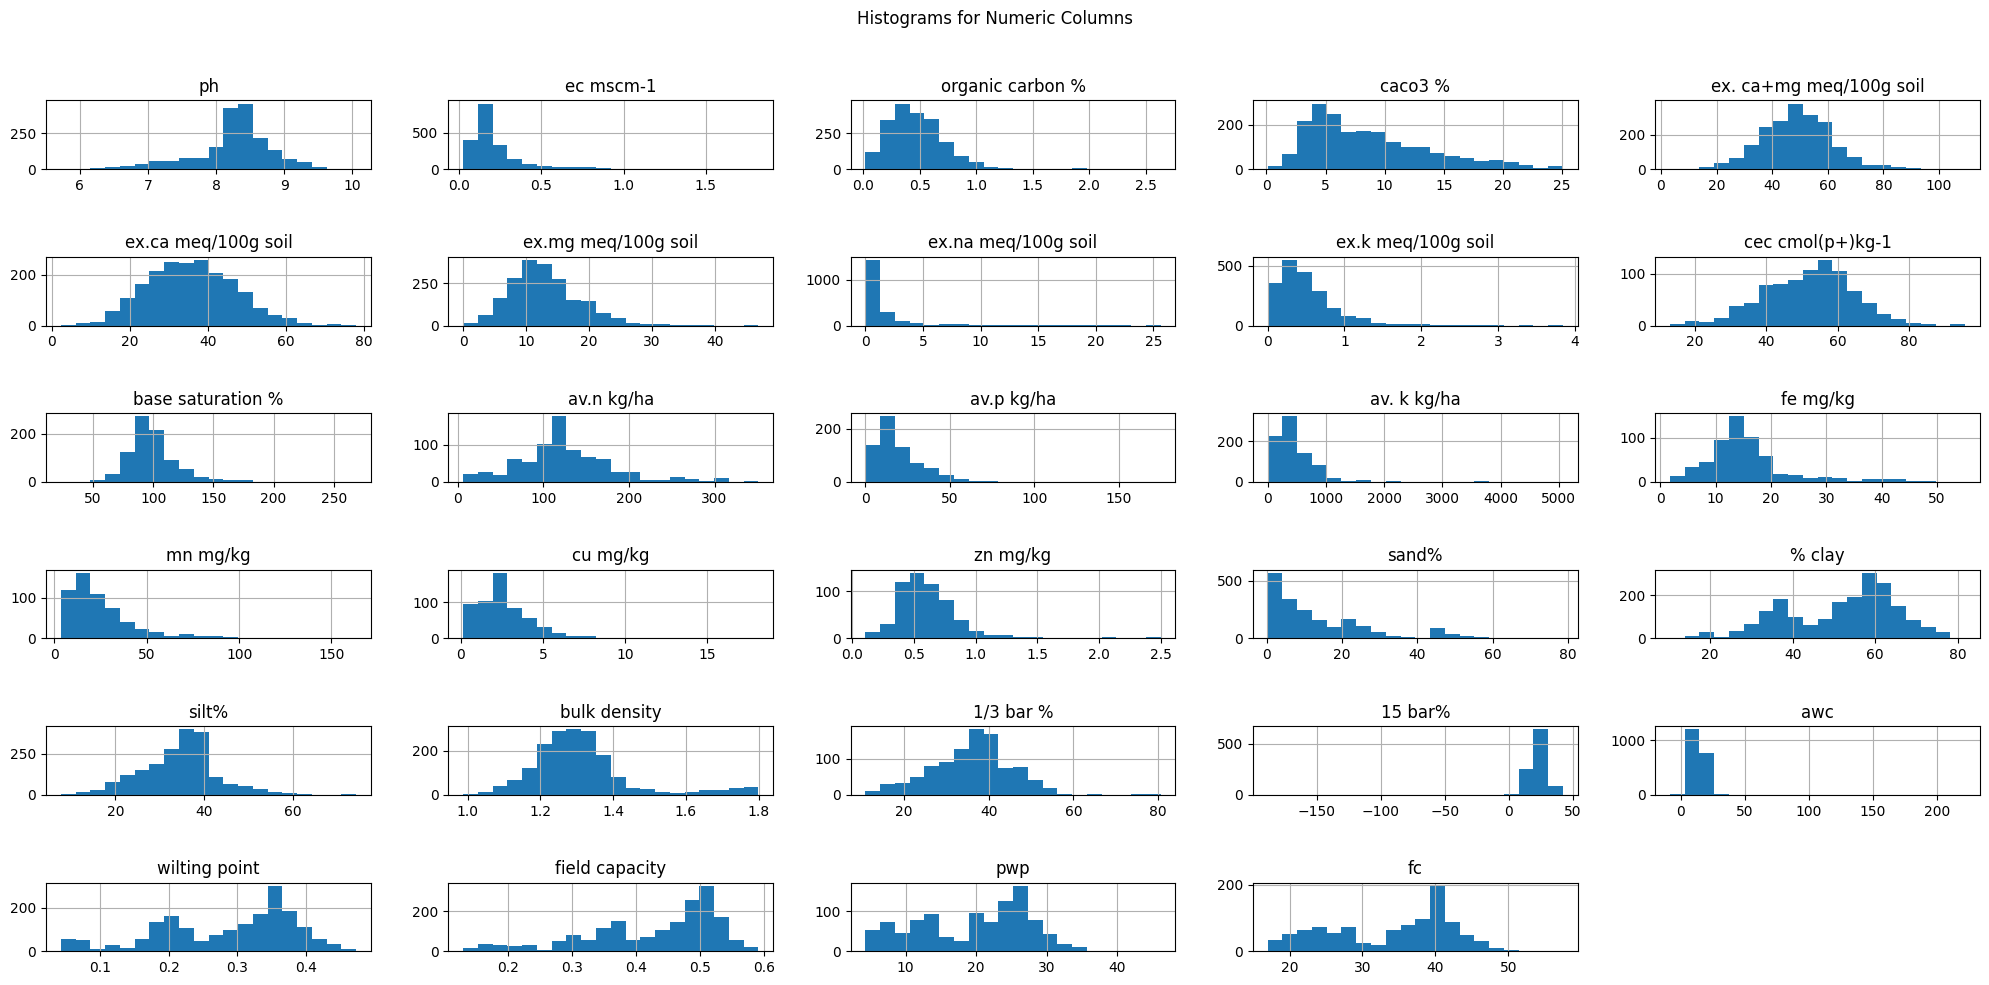

In [ ]:
num_cols = for_num_data.select_dtypes(include=['number']).columns
axarr = for_num_data[num_cols].hist(bins=20, figsize=(20, 10))
plt.suptitle('Histograms for Numeric Columns')
plt.tight_layout(rect=[0, 0, 1, 0.96], h_pad=3.0, w_pad=2.0)  # increase h_pad for more vertical space

plt.show()

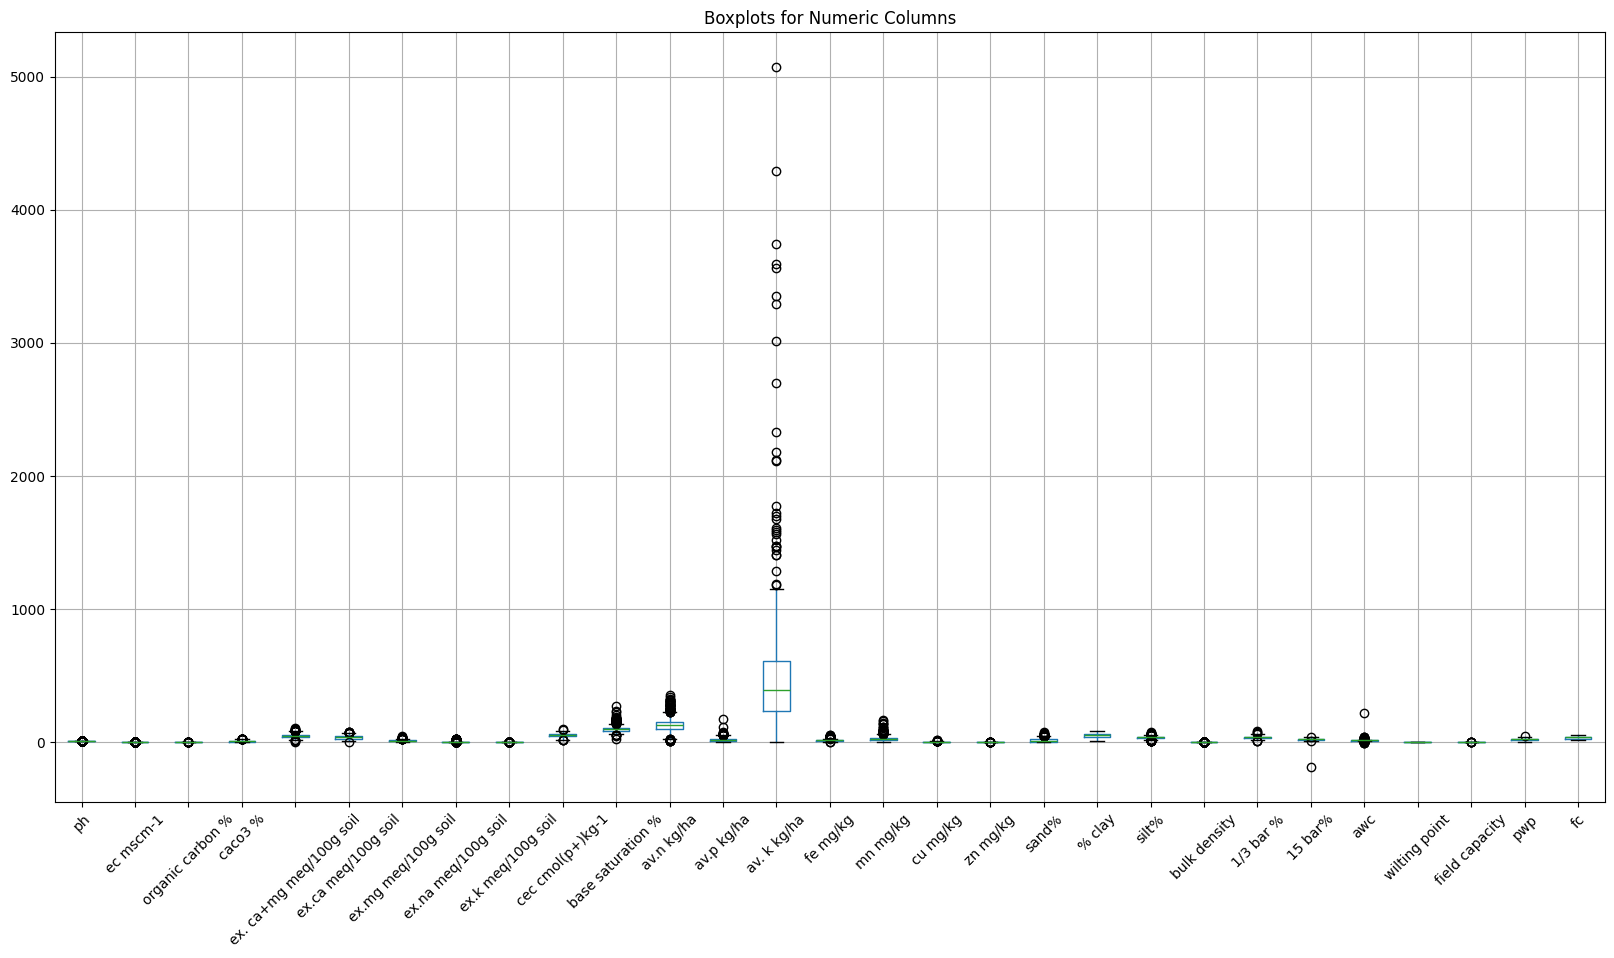

In [ ]:
plt.figure(figsize=(20, 10))
for_num_data[num_cols].boxplot()
plt.title('Boxplots for Numeric Columns')
plt.xticks(rotation=45)
plt.show()

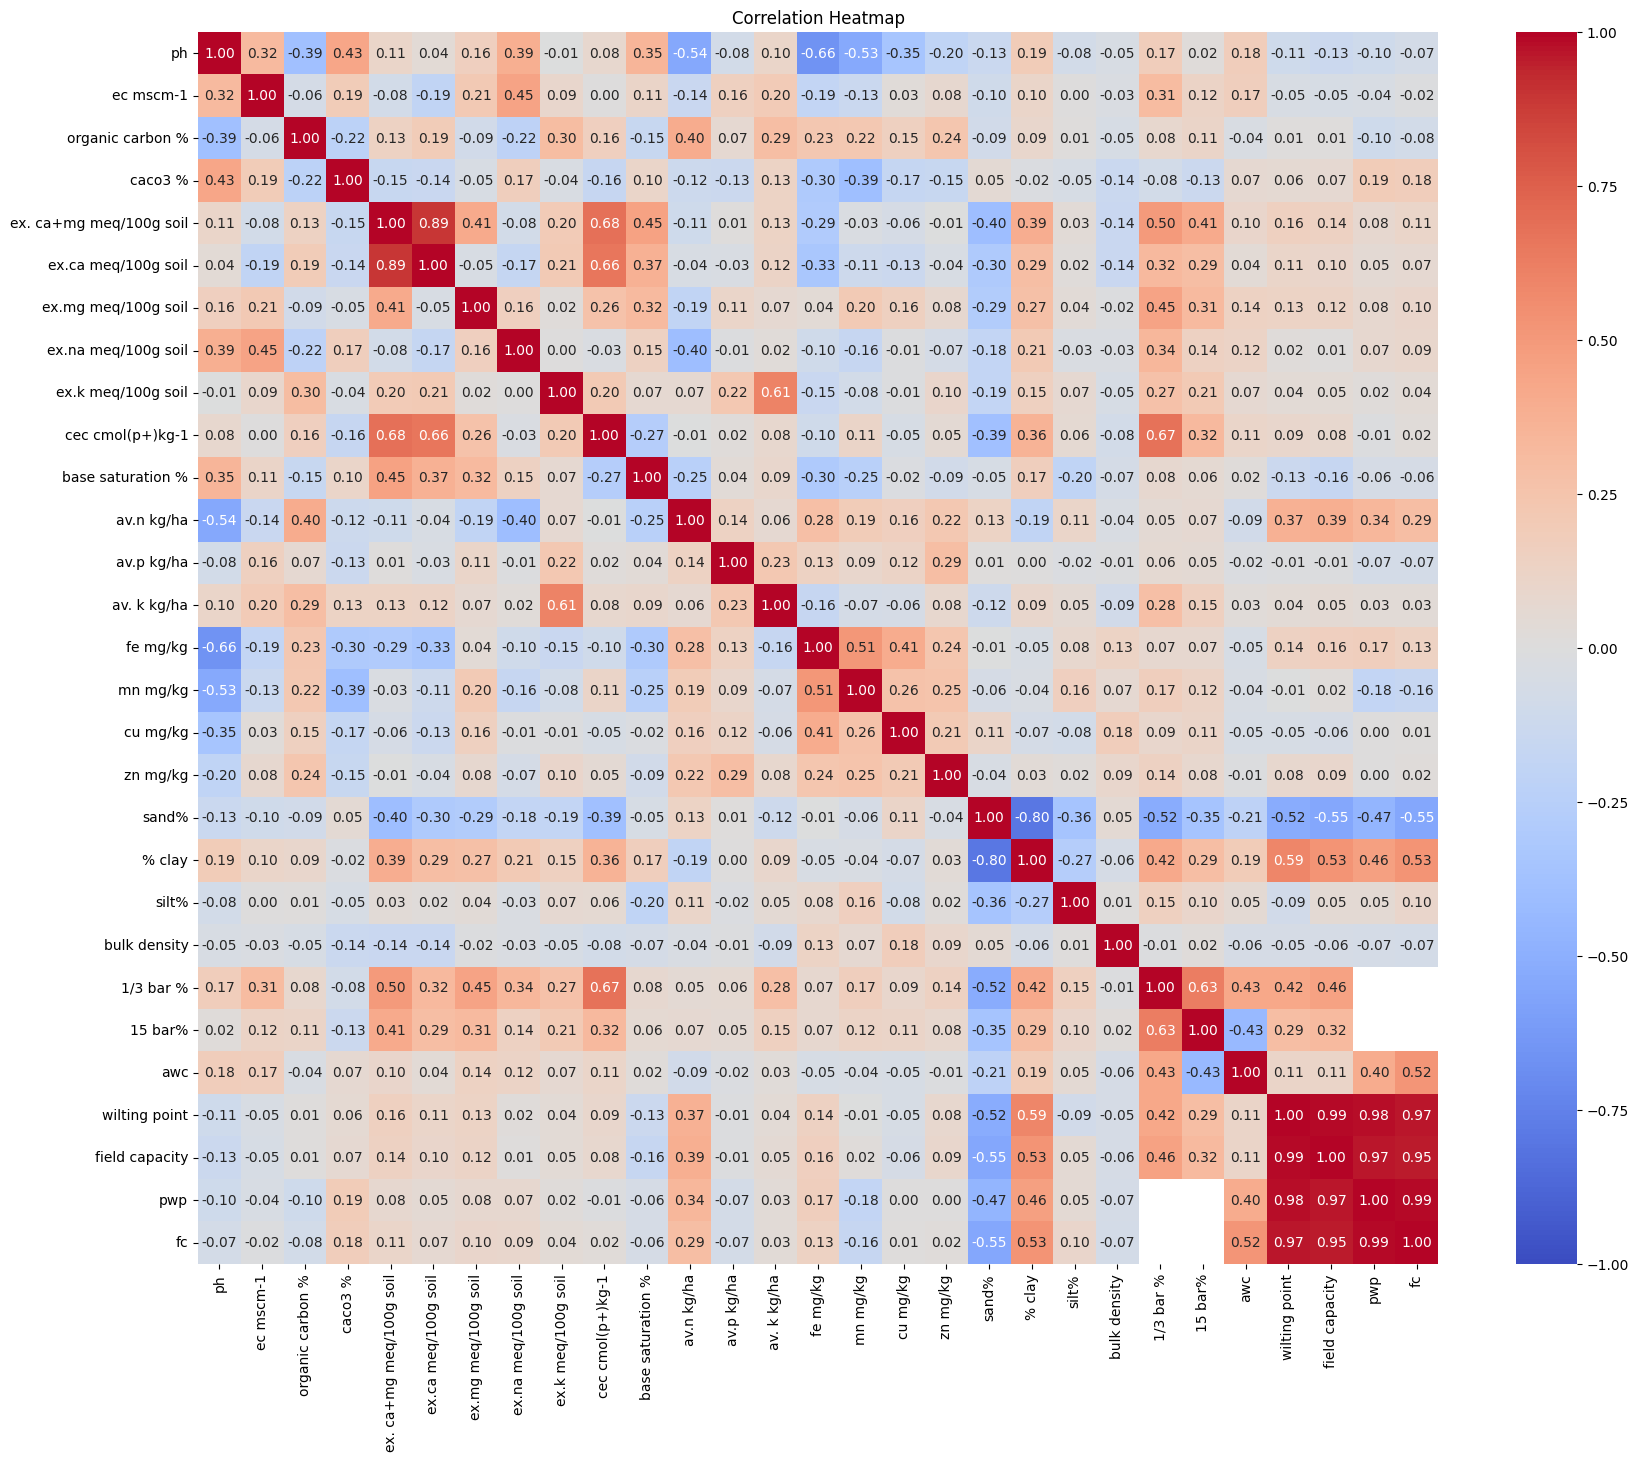

In [ ]:
if len(num_cols) <= 10:
    sns.pairplot(for_num_data[num_cols])
    plt.suptitle('Pairplot for Numeric Columns', y=1.02)
    plt.show()

corr = for_num_data[num_cols].corr()
plt.figure(figsize=(20, 16))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.show()

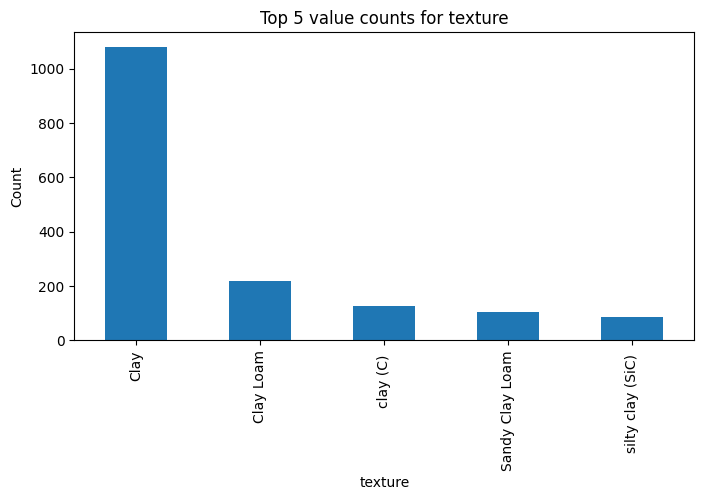

In [ ]:
cat_cols = ["texture"]
col = "texture"
plt.figure(figsize=(8, 4))
latur[col].value_counts().head(5).plot(kind='bar')
plt.title(f"Top 5 value counts for {col}")
plt.ylabel("Count")
plt.xlabel(col)
plt.show()


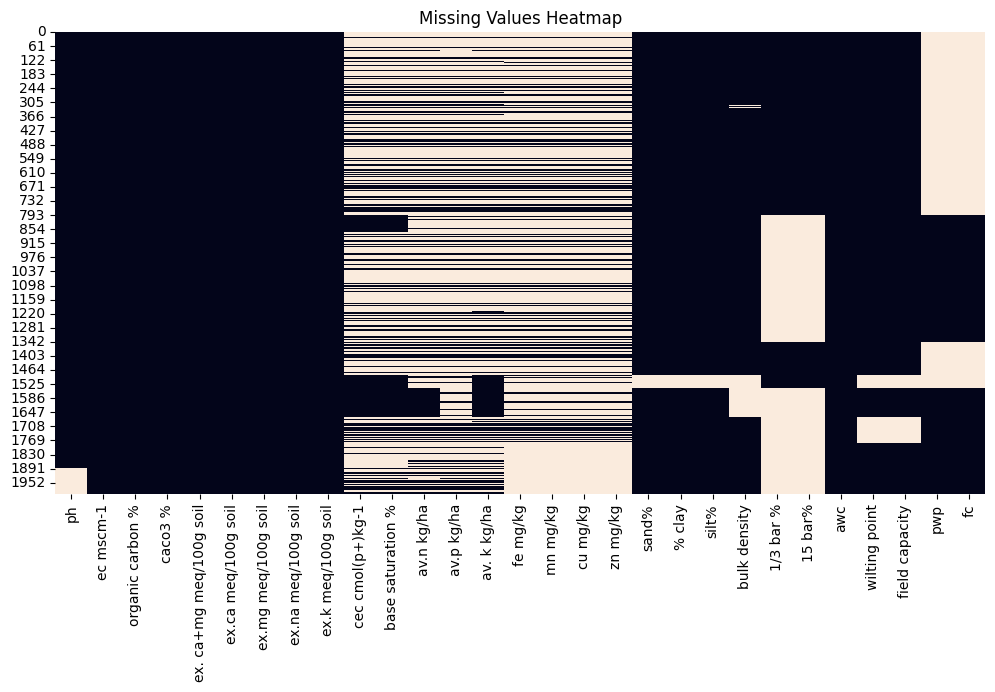

In [ ]:
plt.figure(figsize=(12, 6))
sns.heatmap(for_num_data.isnull(), cbar=False)
plt.title('Missing Values Heatmap')
plt.show()

In [ ]:
print("\nColumns with most missing values:")
print(for_num_data.isnull().sum().sort_values(ascending=False).head(10))

print("\nHighly correlated variable pairs (>0.8):")
for col in corr.columns:
    for idx in corr.index:
        if col != idx and abs(corr.loc[idx, col]) > 0.8:
            print(f"{col} and {idx}: {corr.loc[idx, col]:.2f}")



Columns with most missing values:
fe mg/kg             1417
zn mg/kg             1417
cu mg/kg             1417
mn mg/kg             1417
av.p kg/ha           1317
av.n kg/ha           1220
av. k kg/ha          1177
base saturation %    1149
cec cmol(p+)kg-1     1148
1/3 bar %            1013
dtype: int64

Highly correlated variable pairs (>0.8):
ex. ca+mg meq/100g soil and ex.ca meq/100g soil: 0.89
ex.ca meq/100g soil and ex. ca+mg meq/100g soil: 0.89
sand% and % clay: -0.80
% clay and sand%: -0.80
wilting point and field capacity: 0.99
wilting point and pwp: 0.98
wilting point and fc: 0.97
field capacity and wilting point: 0.99
field capacity and pwp: 0.97
field capacity and fc: 0.95
pwp and wilting point: 0.98
pwp and field capacity: 0.97
pwp and fc: 0.99
fc and wilting point: 0.97
fc and field capacity: 0.95
fc and pwp: 0.99


In [ ]:
num_cols = for_num_data.select_dtypes(include=['number']).columns

skewness = for_num_data[num_cols].skew()
kurtosis = for_num_data[num_cols].kurt()

summary_stats = pd.DataFrame({
    'Skewness': skewness,
    'Kurtosis': kurtosis
})
summary_stats

,Skewness,Kurtosis
ph,-0.887590,1.465696
ec mscm-1,3.067065,12.986166
organic carbon %,1.398456,6.897242
caco3 %,0.931963,0.278980
ex. ca+mg meq/100g soil,0.223250,0.715923
ex.ca meq/100g soil,0.250601,-0.043741
ex.mg meq/100g soil,0.822244,1.676227
ex.na meq/100g soil,4.226213,21.645867
ex.k meq/100g soil,2.183297,8.432603
cec cmol(p+)kg-1,-0.129898,0.086351


Vidarbha: Nagpur, Amravati, Akola, Gondiya, Bhandara, Yavtamal, Washim, Chandrapur, Gadhchiroli, Wardha and Buldhana...........
Marathwada: Aurangabad, Jalna, Beed, Parbhani, Latur, Nanded, Osmanabad and Hingoli

In [ ]:
# Vi: Amravati, Akola, Washmi, Wardha, Budhana
# Ma: Aurangabad, Jalna, Beed, Parbhani, Latur, Nanded, Osmanabad, Hindoli

In [ ]:
for_num_data.head()

,ph,ec mscm-1,organic carbon %,caco3 %,ex. ca+mg meq/100g soil,ex.ca meq/100g soil,ex.mg meq/100g soil,ex.na meq/100g soil,ex.k meq/100g soil,cec cmol(p+)kg-1,...,% clay,silt%,bulk density,1/3 bar %,15 bar%,awc,wilting point,field capacity,pwp,fc
0,8.38,0.178,0.636364,8.700,42.4,29.6,12.8,0.433913,0.404092,54.2,...,55.190678,43.961864,1.700000,37.704918,24.229075,13.475843,0.328,0.481,NaN,NaN
1,8.50,0.192,0.454545,8.555,45.2,29.2,16.0,0.616522,0.329923,NaN,...,66.880000,32.160000,1.300000,38.235294,22.767857,15.467437,0.403,0.539,NaN,NaN
2,8.66,0.192,0.363636,9.135,39.2,26.8,12.4,0.729565,0.274169,NaN,...,63.730570,35.958549,1.686532,41.409692,27.615063,13.794629,0.383,0.524,NaN,NaN
3,8.60,0.208,0.333333,11.165,43.6,18.8,24.8,0.583478,0.246036,NaN,...,59.883721,33.604651,1.747535,32.706767,20.425532,12.281235,0.357,0.502,NaN,NaN
4,8.62,0.238,0.272727,9.570,40.8,16.0,24.8,0.546957,0.290026,NaN,...,59.720000,39.900000,1.484536,37.759336,24.390244,13.369092,0.357,0.504,NaN,NaN


In [ ]:
!pip install contextily

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 80.7 MB/s eta 0:00:00


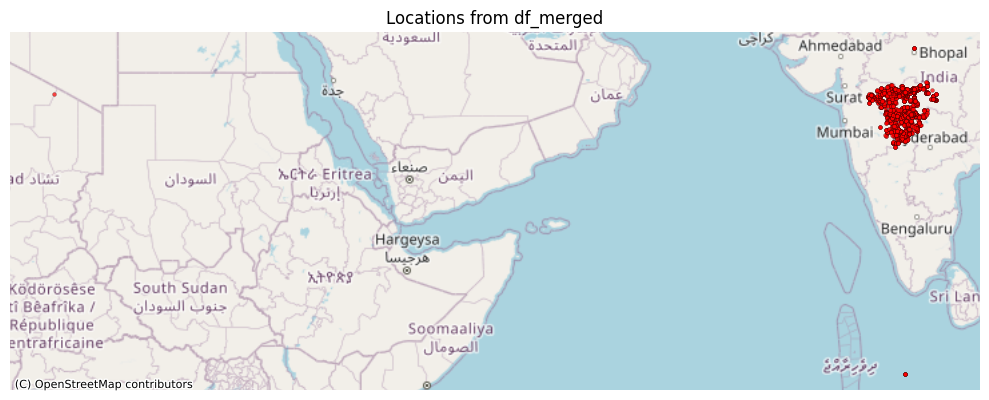

Static map saved as locations_static_map.png


In [ ]:
# --------------------------------------------
# 0.  Install the required packages once:
#     pip install pandas geopandas contextily folium shapely
# --------------------------------------------
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import contextily as cx
import matplotlib.pyplot as plt
import folium
from folium.plugins import MarkerCluster

# ------------------------------------------------------------
# 1.  Read or receive your dataframe (already in memory here)
#     Make sure lat/lon column names match yours exactly
# ------------------------------------------------------------
# df_merged = pd.read_csv("your_file.csv")   # example load
# ... or the dataframe is already defined …

LAT_COL  = "lat"
LON_COL  = "long"

# Keep only rows with finite coordinates
df_valid = df_merged[[LAT_COL, LON_COL]].dropna()
df_valid = df_valid[
    df_valid[LAT_COL].between(-90, 90) & df_valid[LON_COL].between(-180, 180)
]

# ------------------------------------------------------------
# 2A. STATIC MAP  (GeoPandas + Contextily)
# ------------------------------------------------------------
gdf = gpd.GeoDataFrame(
    df_valid,
    geometry=gpd.points_from_xy(df_valid[LON_COL], df_valid[LAT_COL]),
    crs="EPSG:4326",            # WGS-84
)
# Re-project to Web-Mercator for tiled basemaps
gdf_web = gdf.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(10, 10))
gdf_web.plot(ax=ax, markersize=8, alpha=0.7, color="red", edgecolor="k", linewidth=0.2)
cx.add_basemap(ax, crs=gdf_web.crs, source=cx.providers.OpenStreetMap.Mapnik)
ax.set_axis_off()
plt.title("Locations from df_merged")
plt.tight_layout()
plt.savefig("locations_static_map.png", dpi=200)
plt.show()

print("Static map saved as locations_static_map.png")



In [ ]:
# ------------------------------------------------------------
# 2B. INTERACTIVE MAP  (Folium)
#      – great for sharing; supports pan/zoom & pop-ups
# ------------------------------------------------------------
# Centre the map on the mean lat/lon
center_lat = df_valid[LAT_COL].mean()
center_lon = df_valid[LON_COL].mean()

m = folium.Map(location=[center_lat, center_lon], zoom_start=5, tiles="OpenStreetMap")

# Cluster markers if you have many points; switch to plain folium.Marker loop
# for datasets < ~500 points if you prefer.
cluster_layer = MarkerCluster().add_to(m)
for _idx, row in df_valid.iterrows():
    folium.Marker(
        location=[row[LAT_COL], row[LON_COL]],
        tooltip=f"({row[LAT_COL]:.4f}, {row[LON_COL]:.4f})"
    ).add_to(cluster_layer)

m.save("locations_interactive_map.html")
print("Interactive map saved as locations_interactive_map.html")

Interactive map saved as locations_interactive_map.html


In [ ]:
a,b = 0,0
dist = []
coordinates = []
for i in range(len(df_merged['long'])):
  if df_merged['long'][i] < 70 or df_merged['long'][i] > 80:
    a+= 1
    dist.append(df_merged['district'][i])
    coordinates.append(df_merged['long'][i])

for j in range(len(df_merged['lat'])):
  if df_merged['lat'][j] < 15 or df_merged['lat'][j] > 22:
    b+=1
    dist.append(df_merged['district'][j])
    coordinates.append(df_merged['lat'][j])

print("Count of distorted logitudes",a, "\nCount of distorted latitudes", b)
print(dist)
print(coordinates)

Count of distorted logitudes 1 
Count of distorted latitudes 15
['Jalgaon', 'Amravati', 'Amravati', 'Amravati', 'Amravati', 'Amravati', 'Akola', 'Akola', 'Akola', 'Akola', 'Akola', 'Akola', 'Akola', 'Akola', 'Akola', 'Akola']
[np.float64(20.75635), np.float64(23.5909), np.float64(23.5909), np.float64(23.5909), np.float64(23.5909), np.float64(23.5909), np.float64(203.9557), np.float64(203.9557), np.float64(203.9557), np.float64(203.9557), np.float64(203.9557), np.float64(2.8419), np.float64(2.8419), np.float64(2.8419), np.float64(2.8419), np.float64(2.8419)]


In [ ]:
# Start with pH, AwC, soil type

Parbhani, Nanded, Hingoli, Aurangabad, Amravati, Budhana, Jalgaon, Washim, Nashik-Malegaon, Wardha, Akola, Beed, Jalna , Osmanabad